<a href="https://colab.research.google.com/github/Harsh-Aanand/seasonal-agriculture-performance-analysis/blob/main/seasonal-agriculture-performance-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

In [33]:
df.shape

(4000, 28)

In [34]:
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [35]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [37]:
df.isnull().mean()*100

,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,1.2
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


In [38]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [39]:
#Recover missing Yield using Production and Farm Area
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    (df['Production_Tonnes'] / df['Farm_Area_Hectares']).round(2)
)

In [40]:
#Impute seasonal environmental metrics using seasonal medians
df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(
    lambda x: x.fillna(x.median())
)
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(
    lambda x: x.fillna(x.median())
)

In [41]:
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


In [42]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.714313,26.81890,63.210500,7.323050,6.701010,26.504525,120.250825,57.781850,104.760050,...,0.826138,5.262843,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.427366,3.81818,11.960834,1.121186,0.641461,6.696998,31.216452,17.015074,27.742681,...,0.101747,13.343283,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.425000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,581.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,836.125000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [43]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


In [45]:
# Check and report duplicate records
duplicates_count = df.duplicated().sum()
print(f"Total duplicate records found: {duplicates_count}")

Total duplicate records found: 0


In [47]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [48]:
categorical_columns = df.select_dtypes(include="object").columns

#Loop through each categorical column
for col in categorical_columns:
    print(f"\n{col}:")  #column name
    print(df[col].nunique(), "unique values")  # Count of unique values
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [49]:
# Numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [54]:
# 2. Descriptive statistics for numerical features
numerical_summary = df.describe().T[['mean','count', 'std', 'min', '50%','25%', 'max']]
numerical_summary.columns = ['Mean','Count', 'Standard Deviation', 'Min', 'Median (50%)','25%', 'Max']
print("\n--- Numerical Summary Statistics ---")
print(numerical_summary)


--- Numerical Summary Statistics ---
                                        Mean   Count  Standard Deviation  \
Farm_Area_Hectares                  7.888265  4000.0            4.223764   
Rainfall_mm                       600.714313  4000.0          288.427366   
Avg_Temperature_C                  26.818900  4000.0            3.818180   
Humidity_pct                       63.210500  4000.0           11.960834   
Sunlight_Hours_Day                  7.323050  4000.0            1.121186   
Soil_pH                             6.701010  4000.0            0.641461   
Soil_Moisture_pct                  26.504525  4000.0            6.696998   
Nitrogen_kg_ha                    120.250825  4000.0           31.216452   
Phosphorus_kg_ha                   57.781850  4000.0           17.015074   
Potassium_kg_ha                   104.760050  4000.0           27.742681   
Fertilizer_kg_ha                  186.036000  4000.0           60.260583   
Pesticide_Litre_ha                  5.070935  4000

In [57]:
season_summary = df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares                  Rainfall_mm                      \
                     mean median       std        mean  median         std   
Season                                                                       
Kharif           7.944924  8.180  4.282328  852.112676  854.75  181.574933   
Rabi             7.752207  7.680  4.179402  435.937062  430.30  174.685690   
Zaid             8.091246  8.085  4.162594  299.123232  283.30  152.561132   

       Avg_Temperature_C                  Humidity_pct  ...     Profit_INR  \
                    mean median       std         mean  ...            std   
Season                                                  ...                  
Kharif         28.454019   28.5  2.510166    71.812591  ...  611549.783883   
Rabi           23.489183   23.5  2.459561    57.893178  ...  489901.254255   
Zaid           31.042088   31.0  2.554911    52.012121  ...  436356.747261   

       Water_Used_m3                      Water_Efficiency_t_per_1000m3  \
                mean  median          std                          mean   
Season                                                                    
Kharif   6102.201237  4469.0  5670.582696                      5.891834   
Rabi     5846.987093  4292.0  5397.648066                      5.186122   
Zaid     6419.893939  4805.0  5734.619854                      4.413239   

                         Disease_Pest_Risk_pct                    
        median       std                  mean median        std  
Season                                                            
Kharif  3.2770  9.833333             54.467903   54.5  10.087931  
Rabi    2.7400  8.258037             40.482114   40.6  10.104157  
Zaid    2.3015  6.930111             38.216667   37.9   9.873938  

[3 rows x 66 columns]

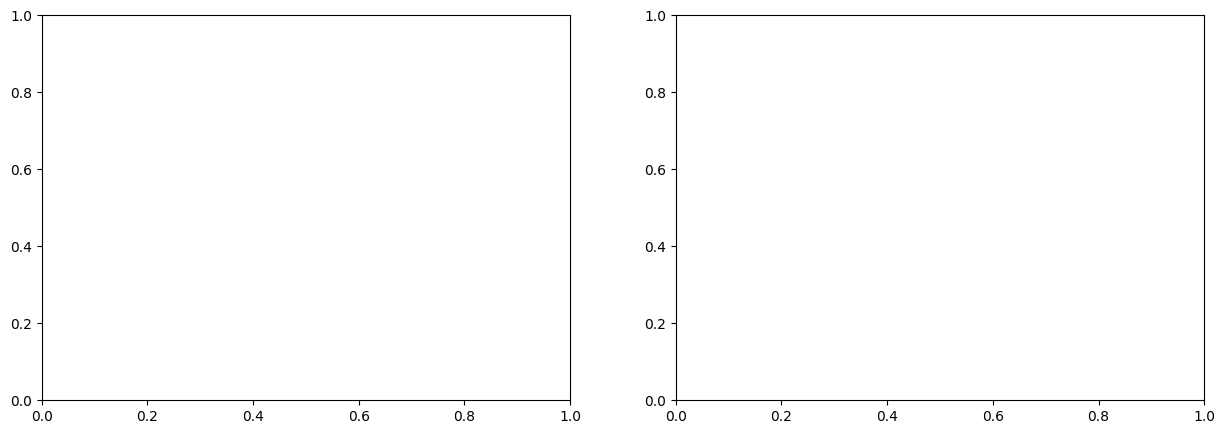

In [59]:
# Investigate Yield and Profit outliers using boxplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

In [67]:
# Quantify outliers using IQR for key numerical features
for col in ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"{col}: {len(outliers)} statistical outliers detected ({len(outliers)/len(df)*100:.1f}%)")

Yield_Tonnes_Ha: 304 statistical outliers detected (7.6%)
Profit_INR: 404 statistical outliers detected (10.1%)
Water_Used_m3: 276 statistical outliers detected (6.9%)


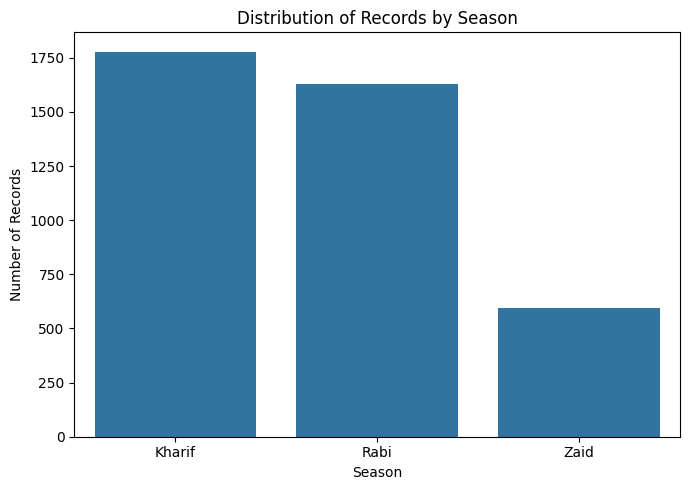

In [70]:
#Univariate : season distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Season")
plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

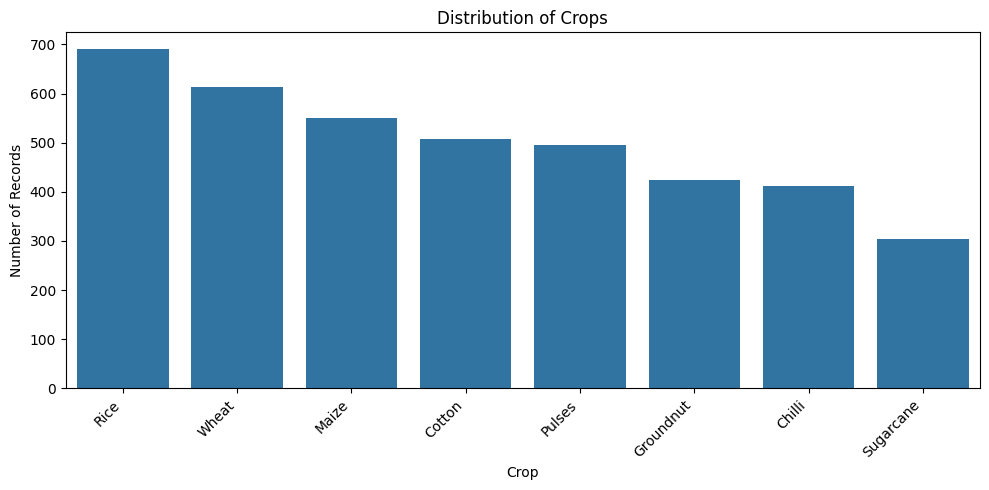

In [72]:
# Univariate: Crop distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks (rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

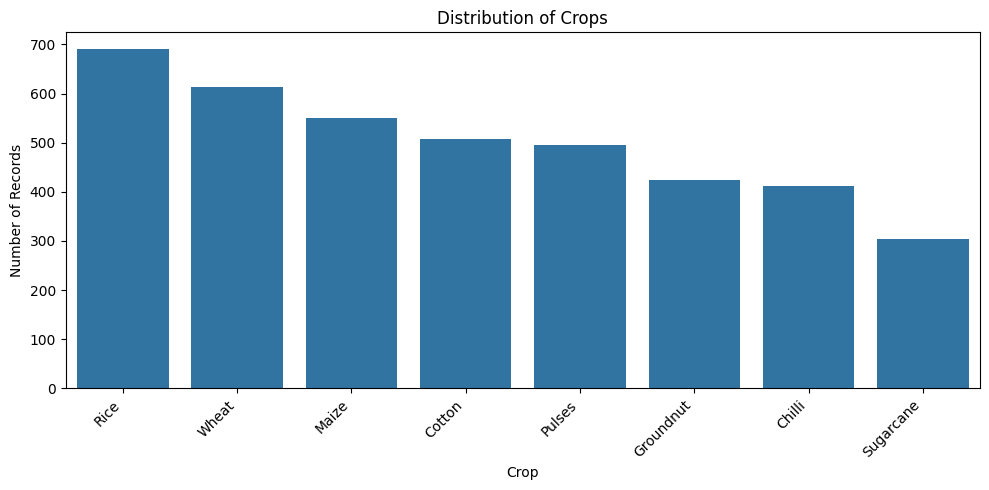

In [73]:
#Univariate : crop distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.xticks (rotation=45, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

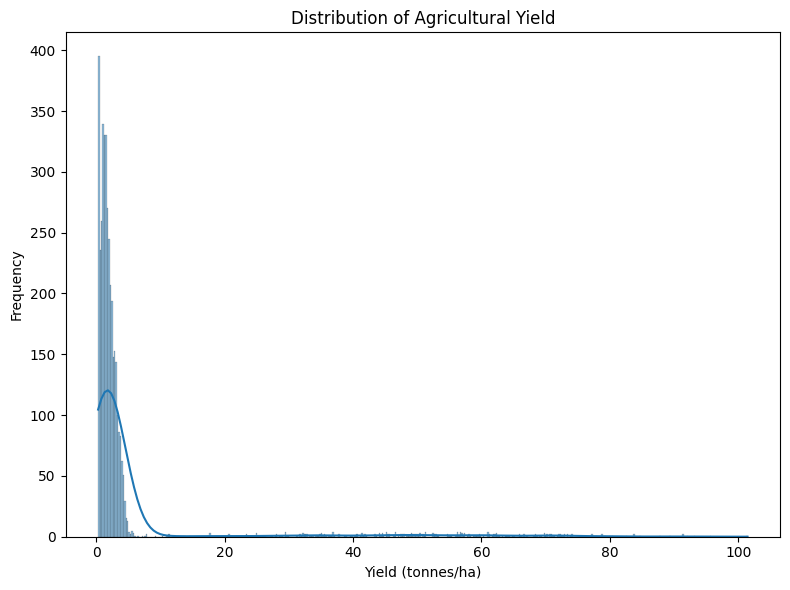

In [77]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x="Yield_Tonnes_Ha", kde=True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

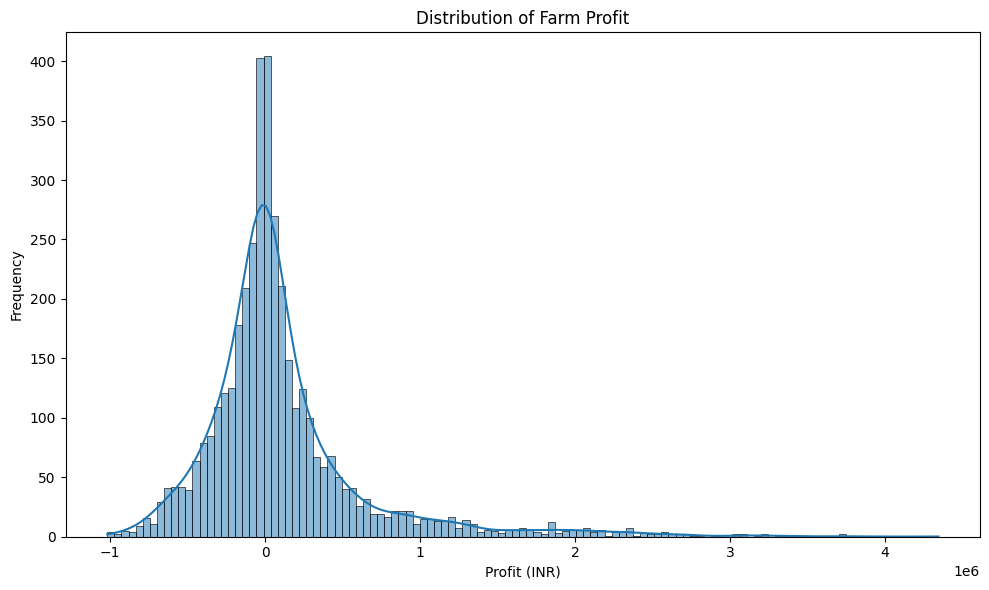

In [80]:
# Univariate: Profit distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Profit_INR", kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

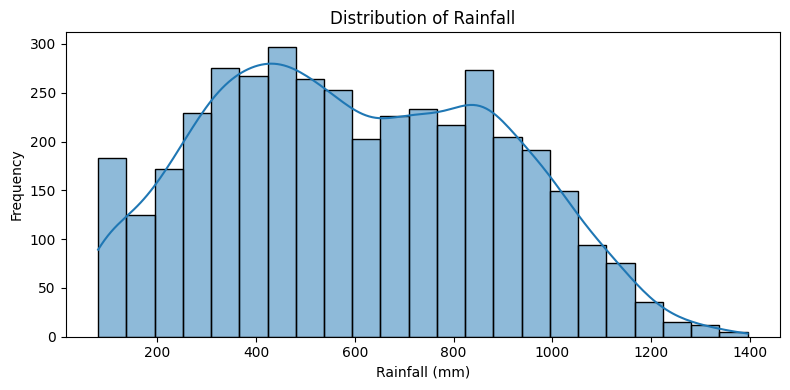

In [82]:
# Univariate: Rainfall distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Rainfall_mm", kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

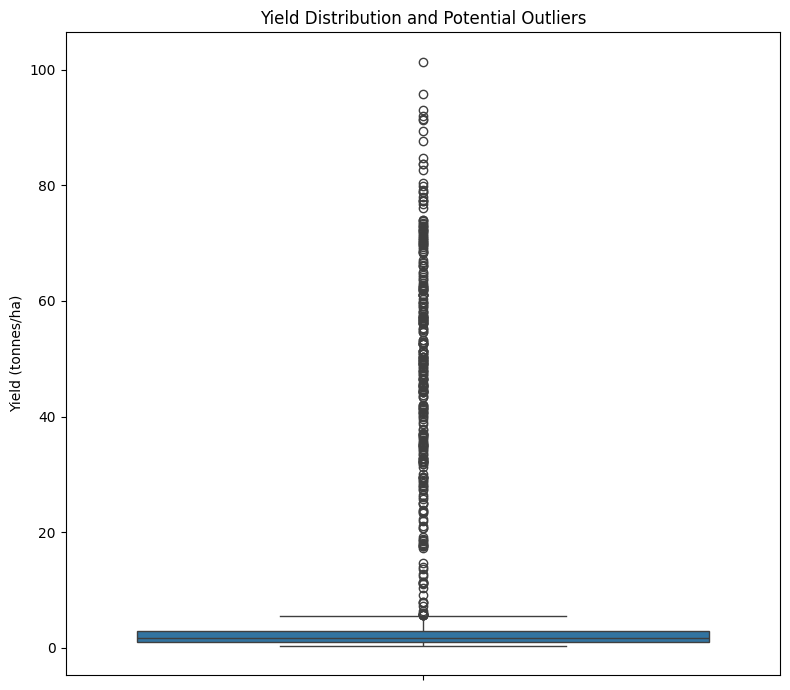

In [91]:
# Univariate: Boxplot for yield
plt.figure(figsize=(8, 7))
sns.boxplot(data=df, y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

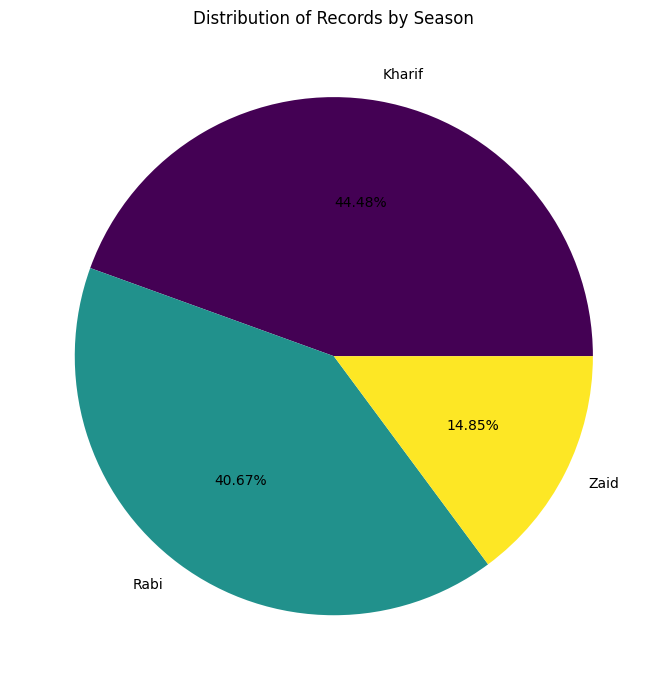

In [112]:
#Univariate: Season distribution (Pie Chart)
plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot.pie(autopct='%1.2f%%', startangle=0, cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # Hide the default 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [99]:
# Compute IQR boundaries and count outliers for every numeric feature
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

iqr_records = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    iqr_records.append({
        'Feature': col,
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round((len(outliers) / len(df)) * 100, 2)
    })

iqr_summary_df = pd.DataFrame(iqr_records)
display(iqr_summary_df)



,Feature,Q1 (25%),Q3 (75%),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Farm_Area_Hectares,4.26,11.65,7.39,-6.83,22.74,0,0.00
1,Rainfall_mm,370.42,836.12,465.70,-328.12,1534.68,0,0.00
2,Avg_Temperature_C,23.90,29.60,5.70,15.35,38.15,2,0.05
3,Humidity_pct,54.78,71.90,17.13,29.09,97.59,6,0.15
4,Sunlight_Hours_Day,6.60,8.10,1.50,4.35,10.35,26,0.65
5,Soil_pH,6.26,7.14,0.88,4.94,8.46,0,0.00
6,Soil_Moisture_pct,21.70,31.20,9.50,7.45,45.45,5,0.12
7,Nitrogen_kg_ha,98.50,141.22,42.72,34.41,205.31,10,0.25
8,Phosphorus_kg_ha,46.20,69.40,23.20,11.40,104.20,16,0.40
9,Potassium_kg_ha,86.20,123.60,37.40,30.10,179.70,32,0.80


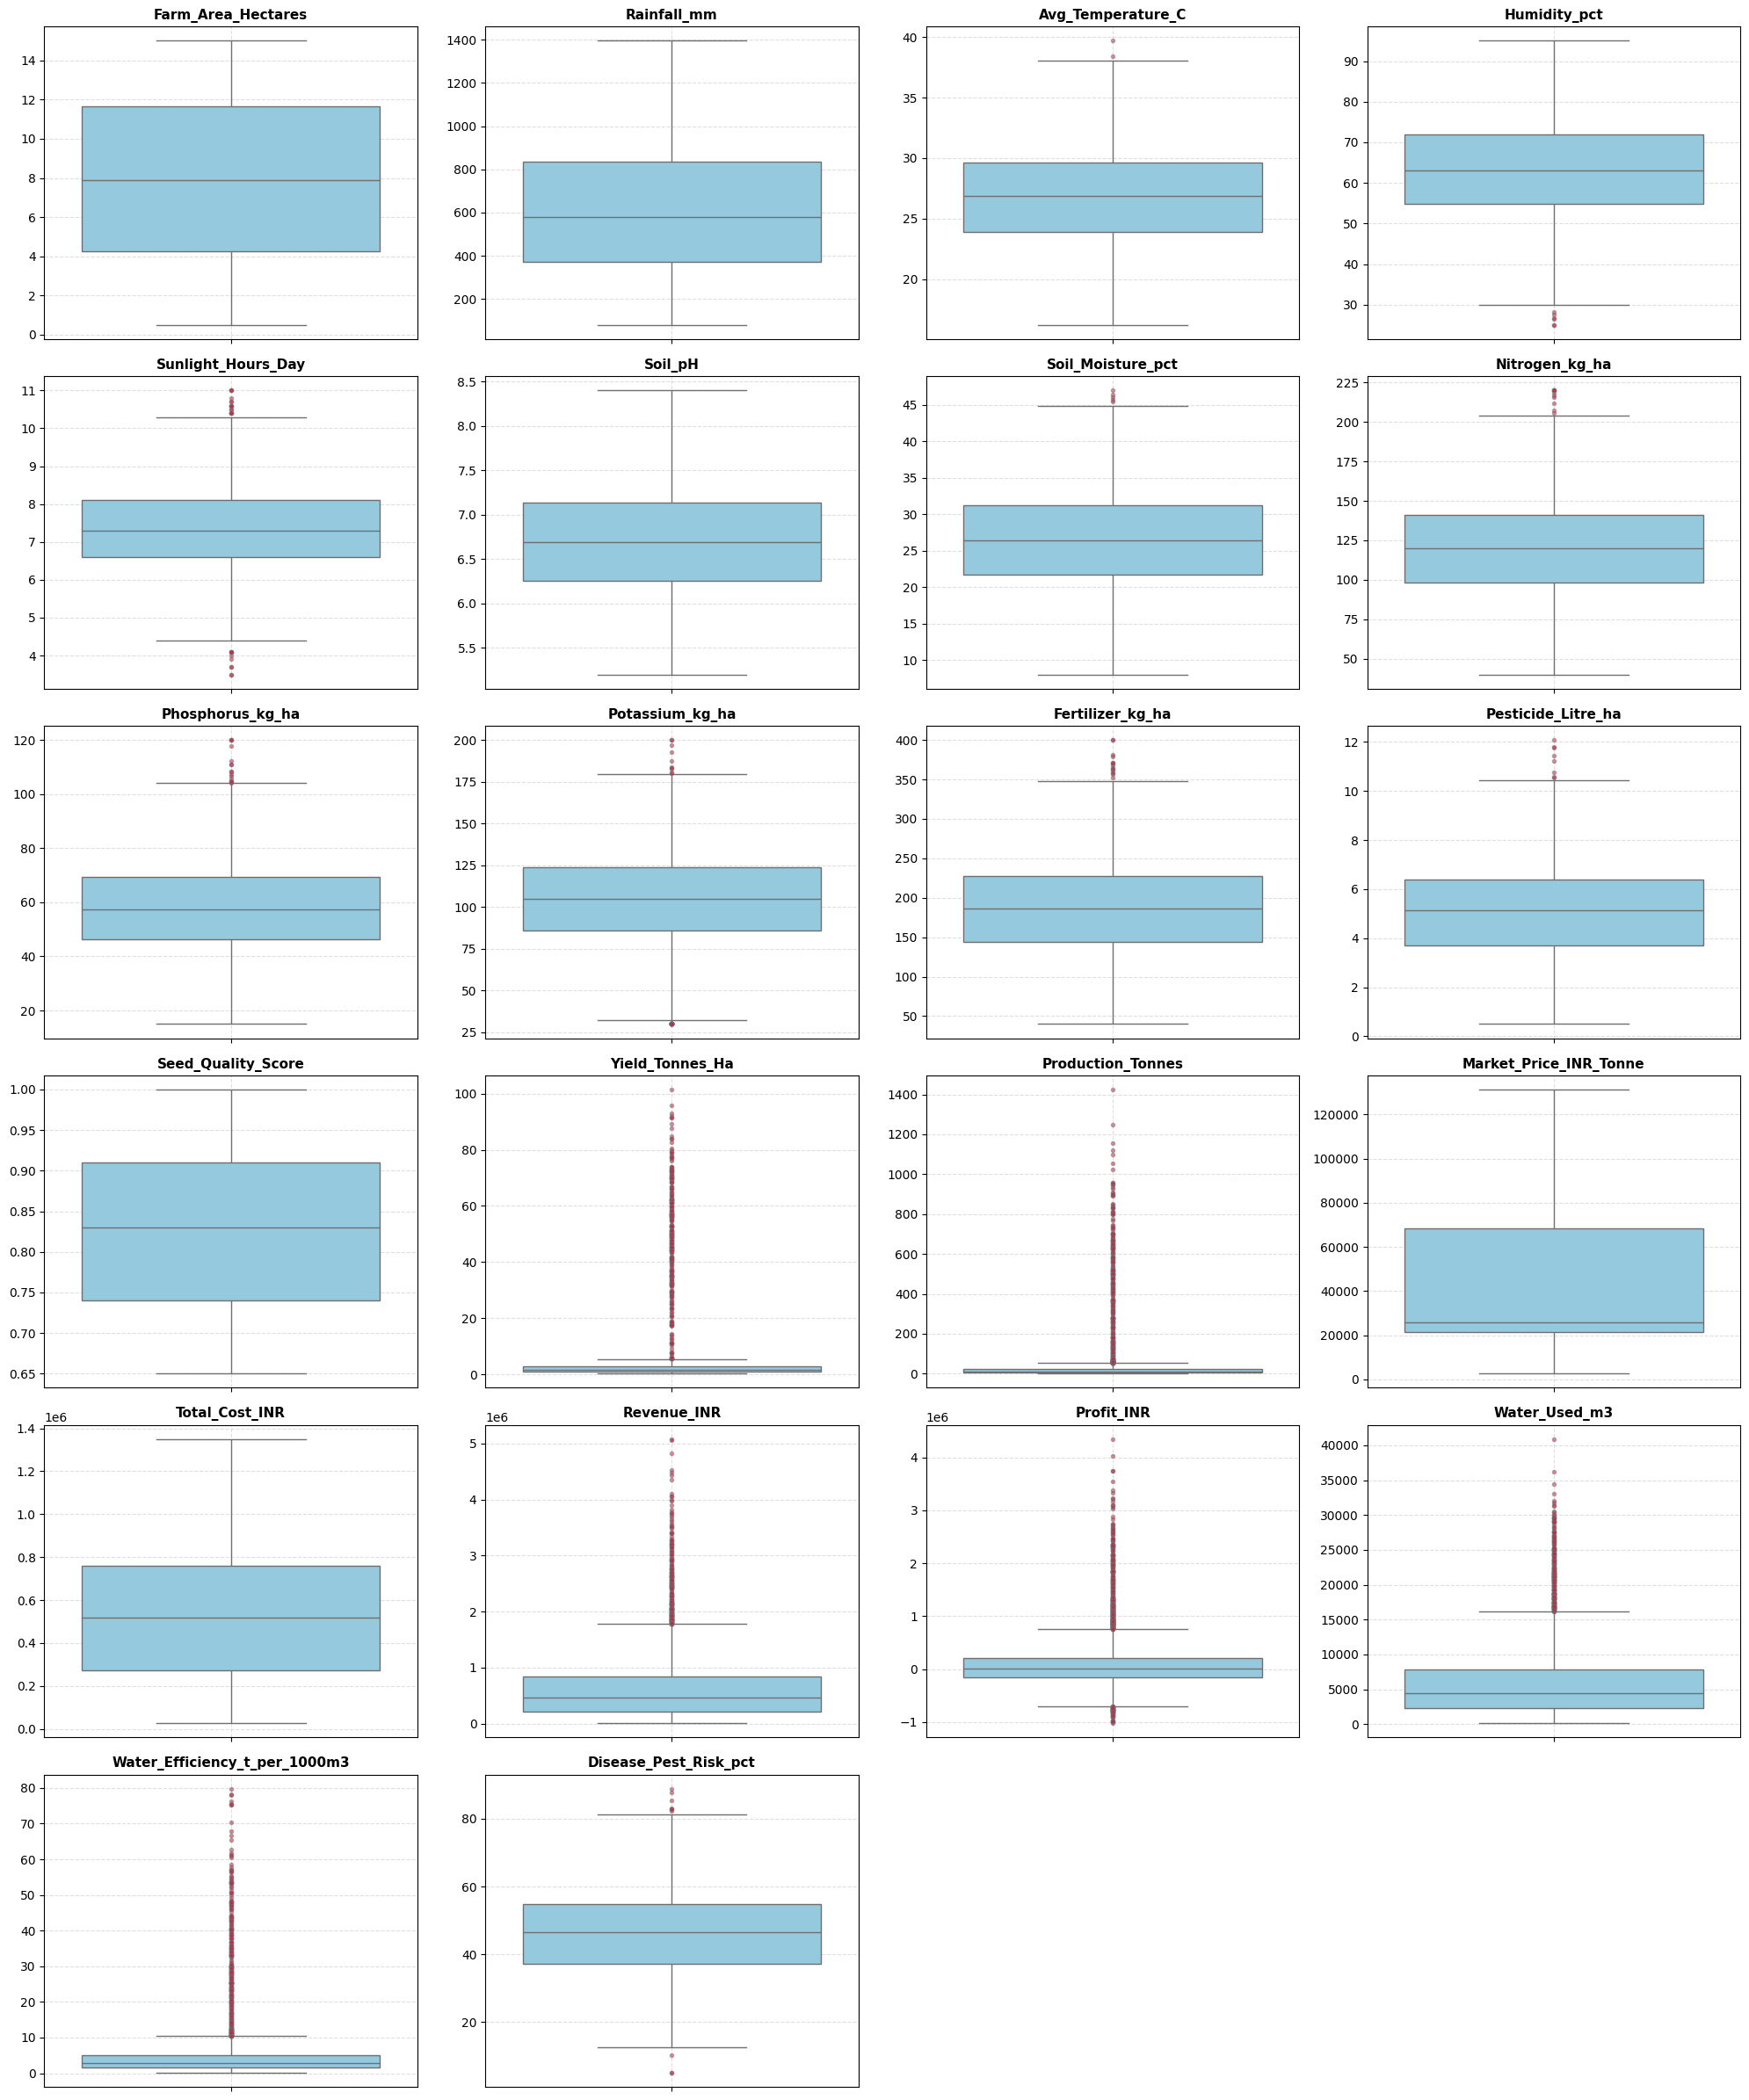

In [100]:
# Grid Boxplots (6 rows x 4 columns grid for 22 features)
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 24))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='skyblue', flierprops=dict(marker='o', markersize=3, markerfacecolor='crimson', alpha=0.5))
    axes[idx].set_title(f"{col}", fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('')
    axes[idx].grid(True, linestyle='--', alpha=0.4)

#off unused subplot slots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

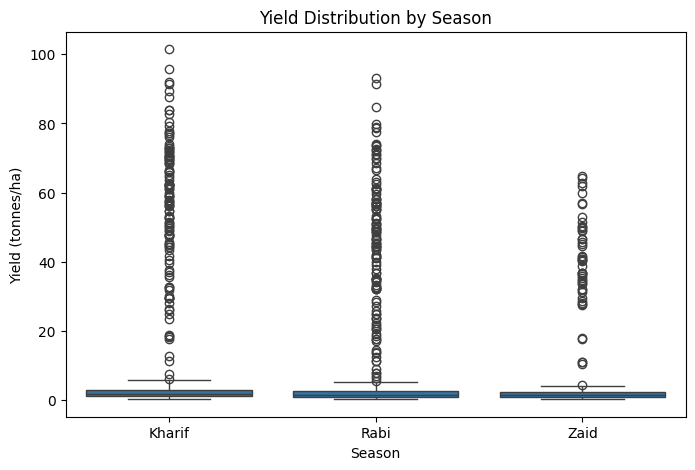

In [101]:
#Bivariate: Season vs yield
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha")
plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout
plt.show()

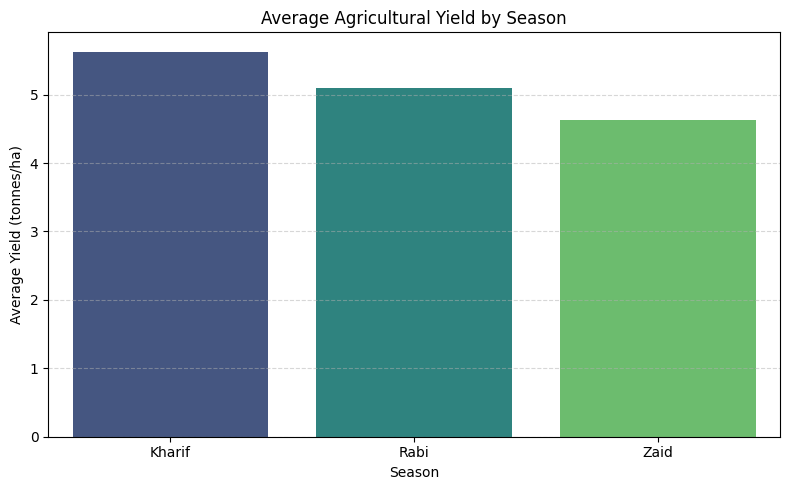

In [102]:
# Bivariate: season vs average yield
plt.figure(figsize=(8, 5))

# Calculate average yield per season
seasonal_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reset_index()

sns.barplot(data=seasonal_yield, x='Season', y='Yield_Tonnes_Ha', palette='viridis', hue='Season', legend=False)
plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (tonnes/ha)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

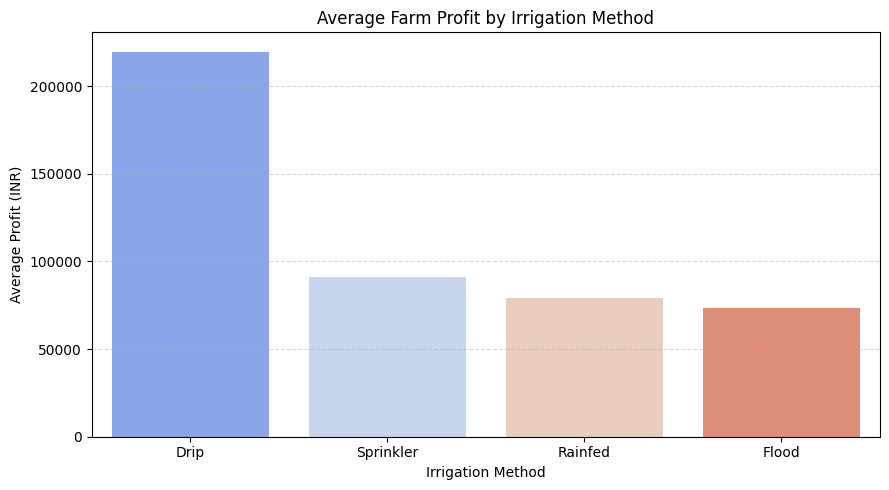

In [106]:
# Bivariate: Irrigation Method vs Average Profit
plt.figure(figsize=(9, 5))

# Calculate average profit per irrigation method
irrigation_profit = df.groupby('Irrigation_Method')['Profit_INR'].mean().reset_index()

irrigation_profit = irrigation_profit.sort_values(by='Profit_INR', ascending=False)

sns.barplot(data=irrigation_profit, x='Irrigation_Method', y='Profit_INR', palette='coolwarm', hue='Irrigation_Method', legend=False)
plt.title('Average Farm Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

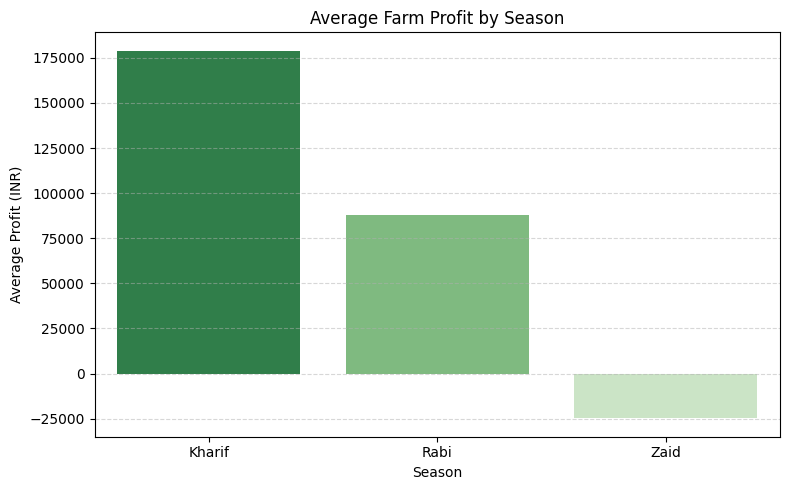

In [107]:
# Bivariate: Season vs Average Profit
plt.figure(figsize=(8, 5))

# Calculate average profit per season
seasonal_profit = df.groupby('Season')['Profit_INR'].mean().reset_index()
# Sort values
seasonal_profit = seasonal_profit.sort_values(by='Profit_INR', ascending=False)

sns.barplot(data=seasonal_profit, x='Season', y='Profit_INR', palette='Greens_r', hue='Season', legend=False)
plt.title('Average Farm Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

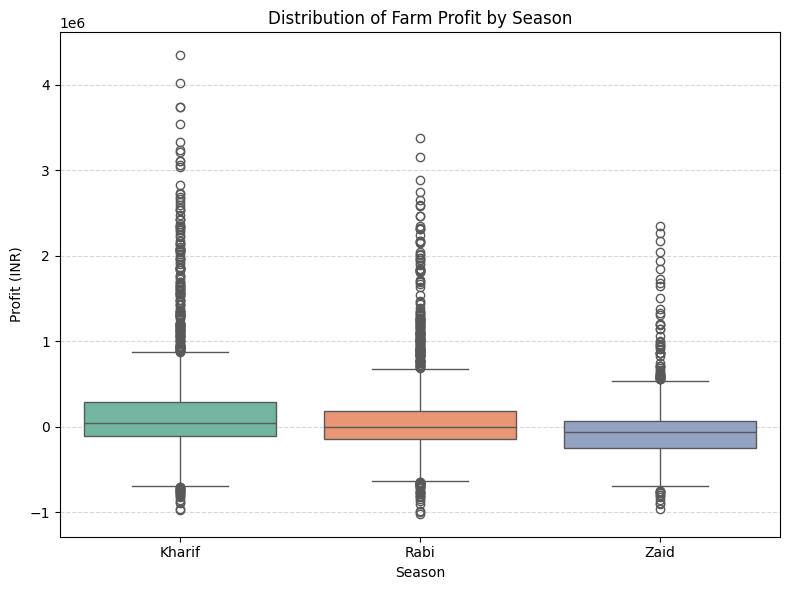

In [109]:
# Bivariate: Season vs Profit_INR Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', palette='Set2', legend=False)
plt.title('Distribution of Farm Profit by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

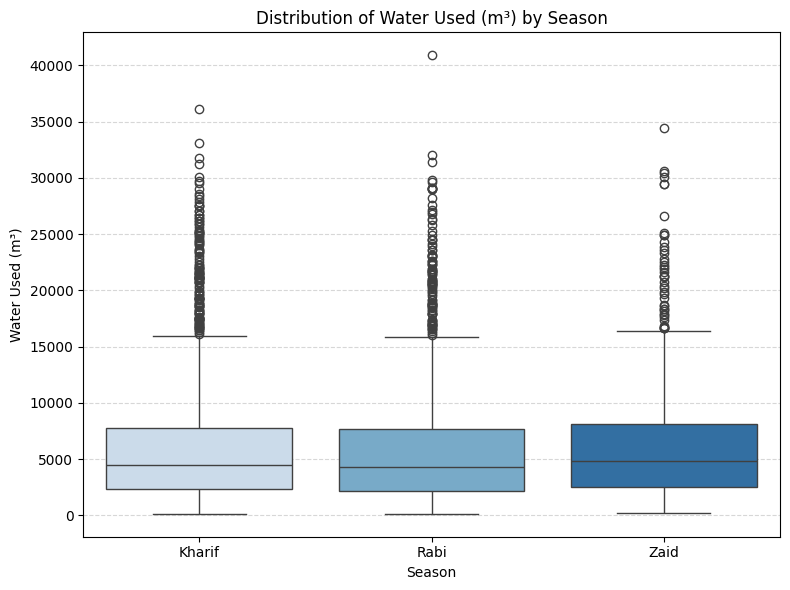

In [113]:
# Bivariate: Season vs Water Used Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Season', y='Water_Used_m3', hue='Season', palette='Blues', legend=False)
plt.title('Distribution of Water Used (m³) by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

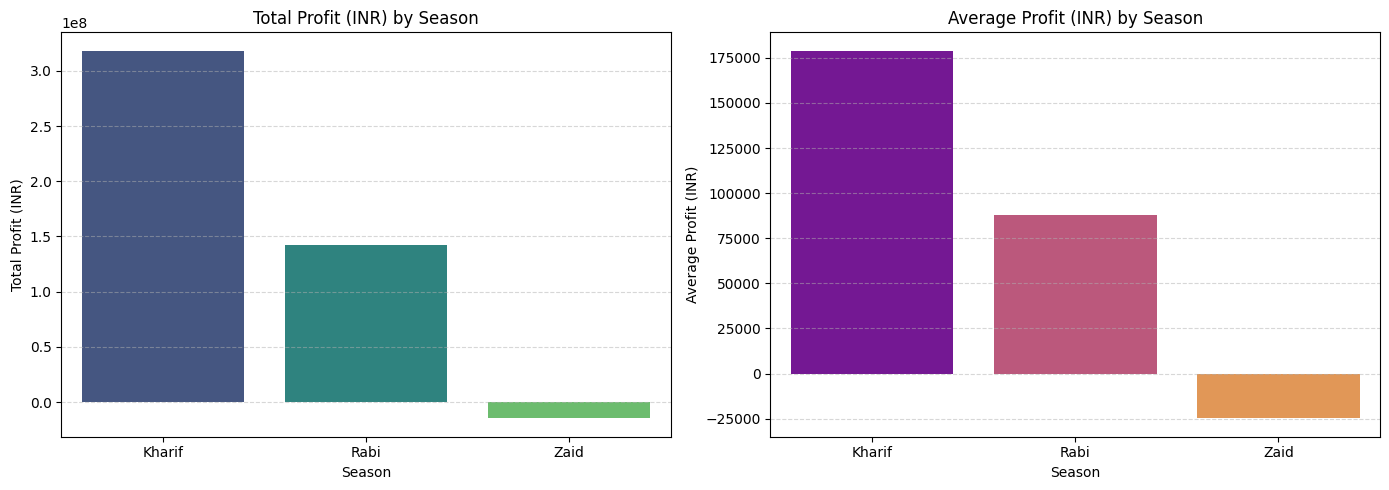

In [114]:
# Bivariate: Total Profit vs Average Profit across Seasons
season_profit_stats = df.groupby('Season')['Profit_INR'].agg(['sum', 'mean']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Profit (INR) by Season
sns.barplot(data=season_profit_stats, x='Season', y='sum', ax=axes[0], palette='viridis', hue='Season', legend=False)
axes[0].set_title('Total Profit (INR) by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Total Profit (INR)')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Plot 2: Average Profit (INR) by Season
sns.barplot(data=season_profit_stats, x='Season', y='mean', ax=axes[1], palette='plasma', hue='Season', legend=False)
axes[1].set_title('Average Profit (INR) by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average Profit (INR)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

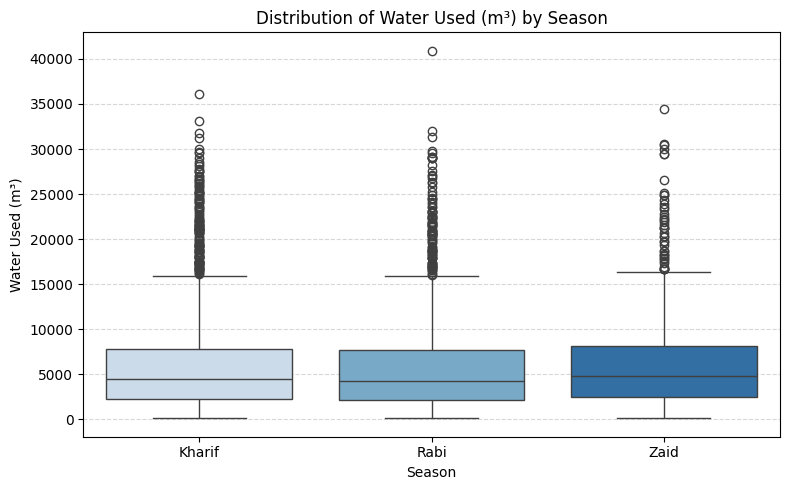

In [116]:
#bivariate : Season vs water usage

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Season', y='Water_Used_m3', hue='Season', palette='Blues', legend=False)
plt.title('Distribution of Water Used (m³) by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


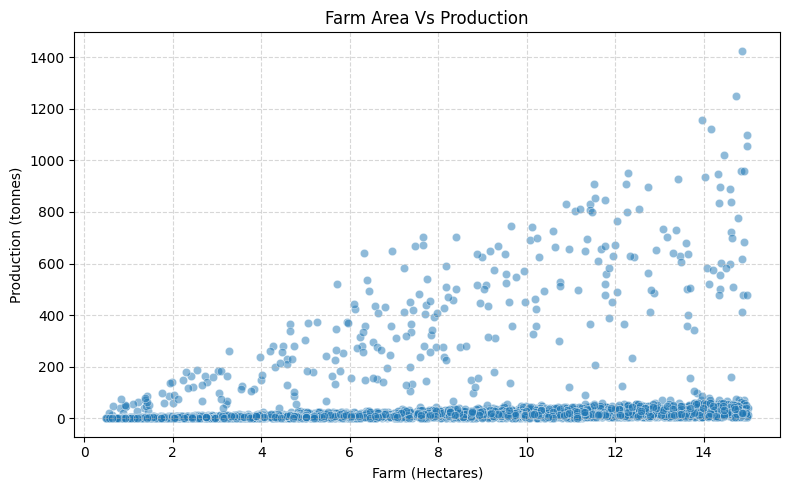

In [126]:
#bivariate: farm area vs production
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Farm_Area_Hectares", y="Production_Tonnes", alpha =  0.5)
plt.title('Farm Area Vs Production')
plt.xlabel('Farm (Hectares)')
plt.ylabel('Production (tonnes)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

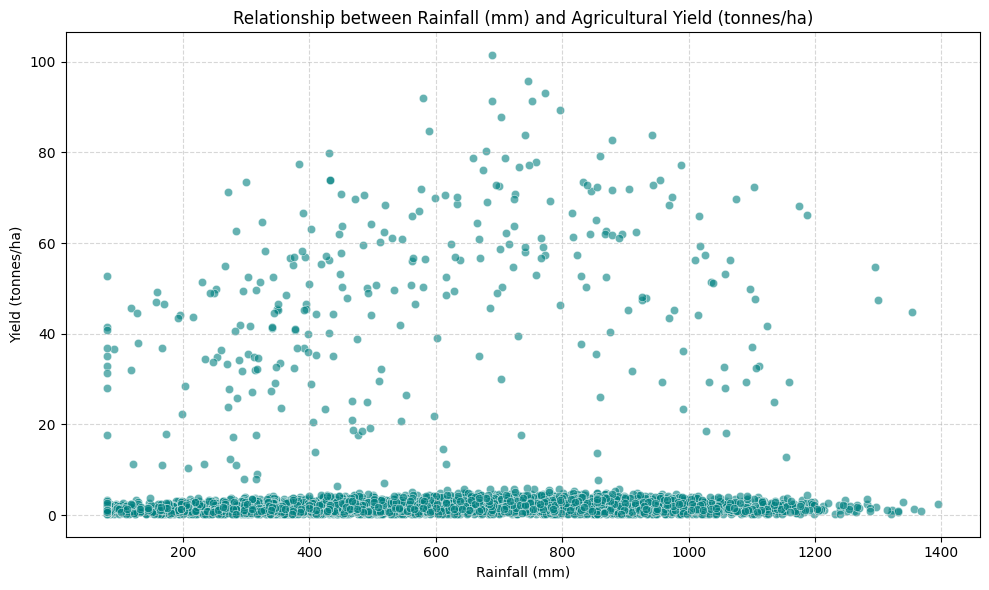

In [117]:
# Bivariate: Rainfall vs Yield scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.6, edgecolor='w', color='teal')
plt.title('Relationship between Rainfall (mm) and Agricultural Yield (tonnes/ha)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (tonnes/ha)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

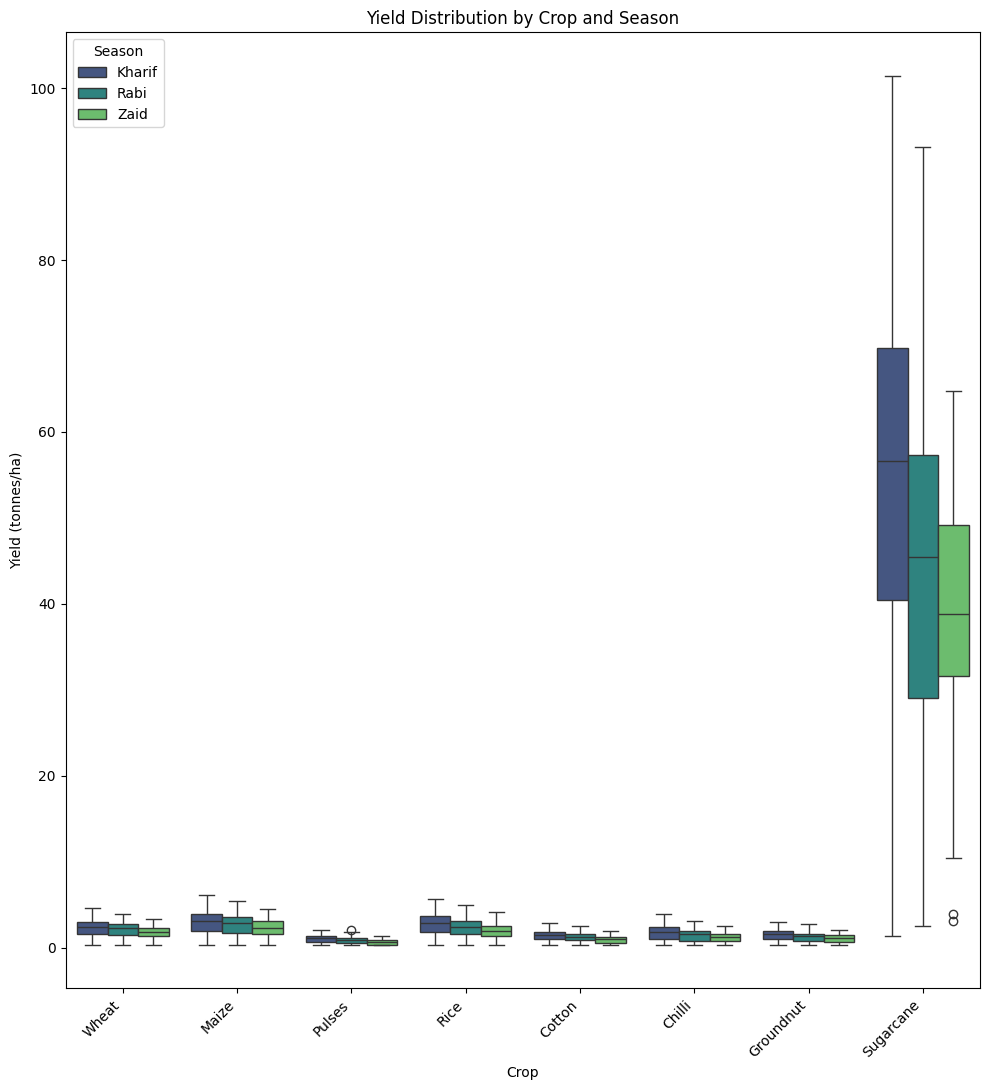

In [131]:
# Multivariate: Season, crop and yield
plt.figure(figsize=(10, 11))
sns.boxplot(data=df, x="Crop", y="Yield_Tonnes_Ha", hue="Season", palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Yield Distribution by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

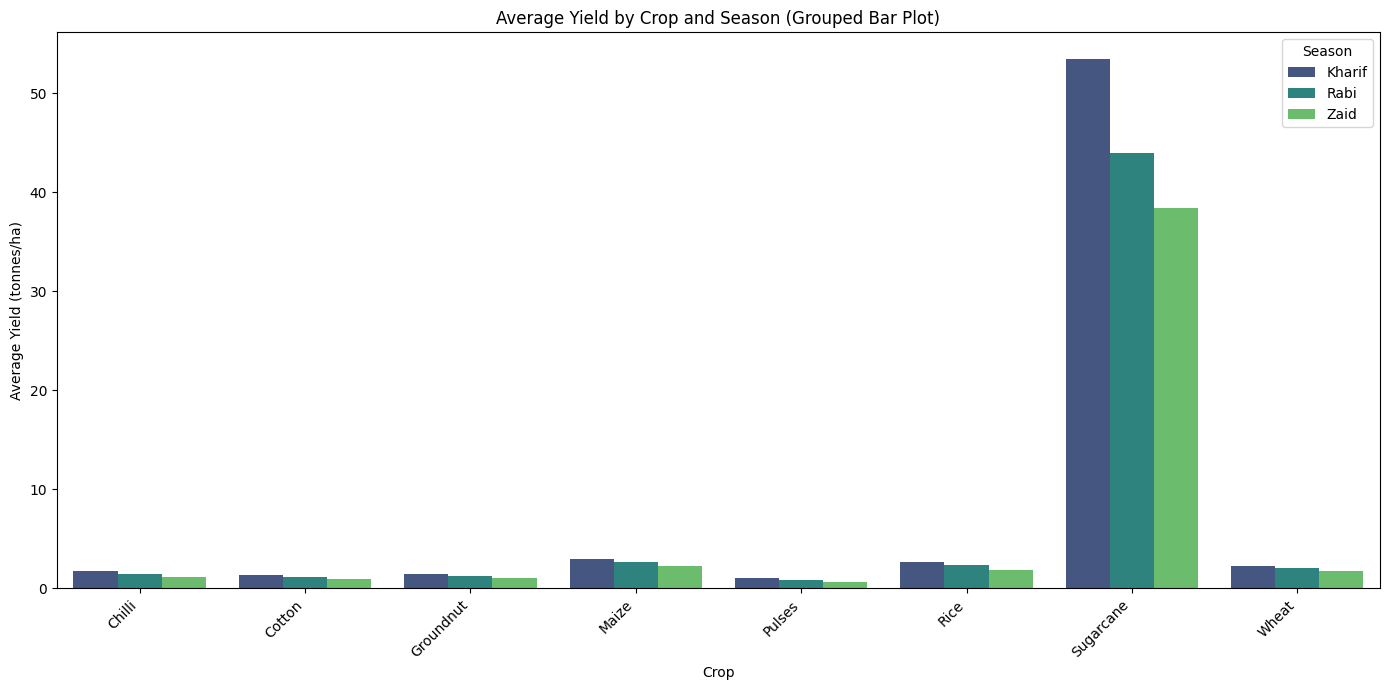

In [134]:
# Calculate the crop seasonal summary to fix NameError
crop_season_summary = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].mean().reset_index(name='Average_Yield')

# Multivariate: Grouped Bar Plot of Average Yield by Crop and Season
plt.figure(figsize=(14, 7))
sns.barplot(data=crop_season_summary, x='Crop', y='Average_Yield', hue='Season', palette='viridis')
plt.title('Average Yield by Crop and Season (Grouped Bar Plot)')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

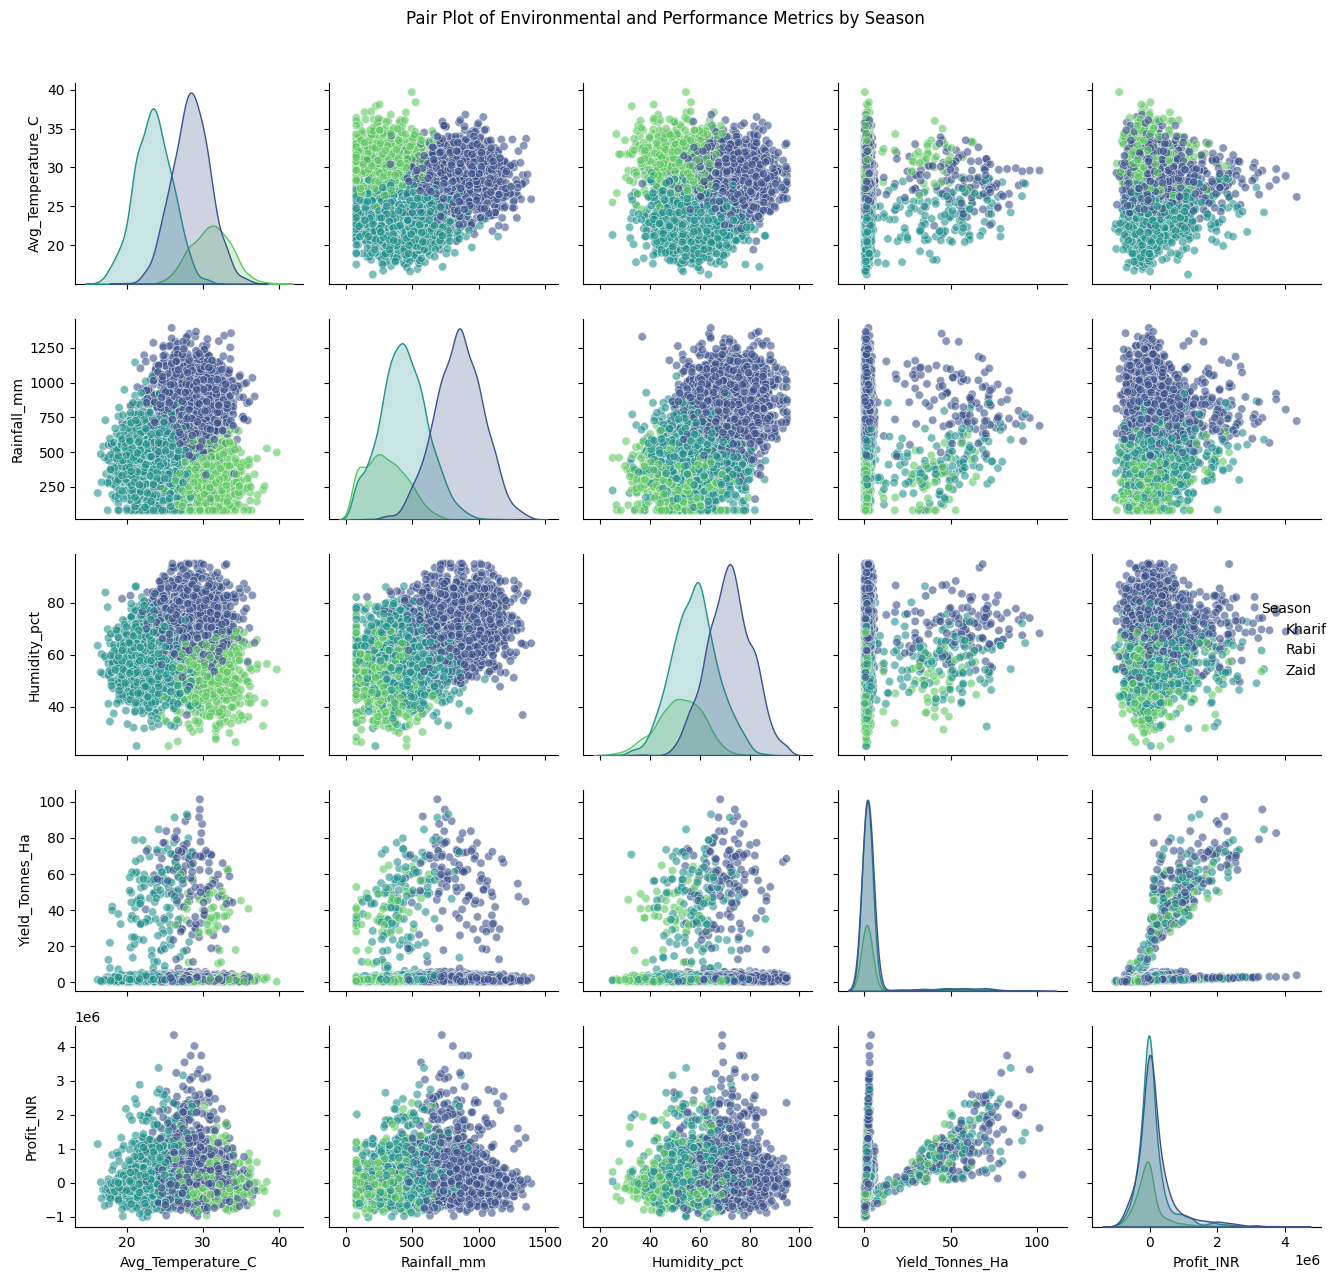

In [133]:
#Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df [selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Environmental and Performance Metrics by Season', y=1.02)
plt.tight_layout()
plt.show()

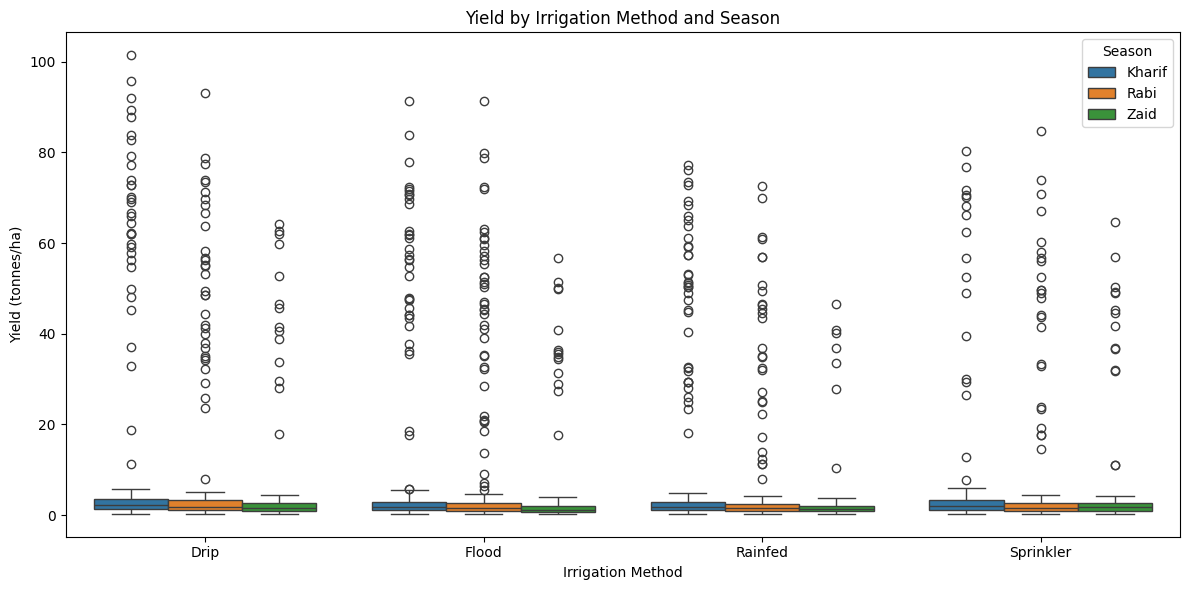

In [135]:
#Multivariate :Yield by Irrigation Method and Season
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Irrigation_Method", y="Yield_Tonnes_Ha", hue="Season")
plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt. legend(title="Season")
plt.tight_layout ()
plt.show()

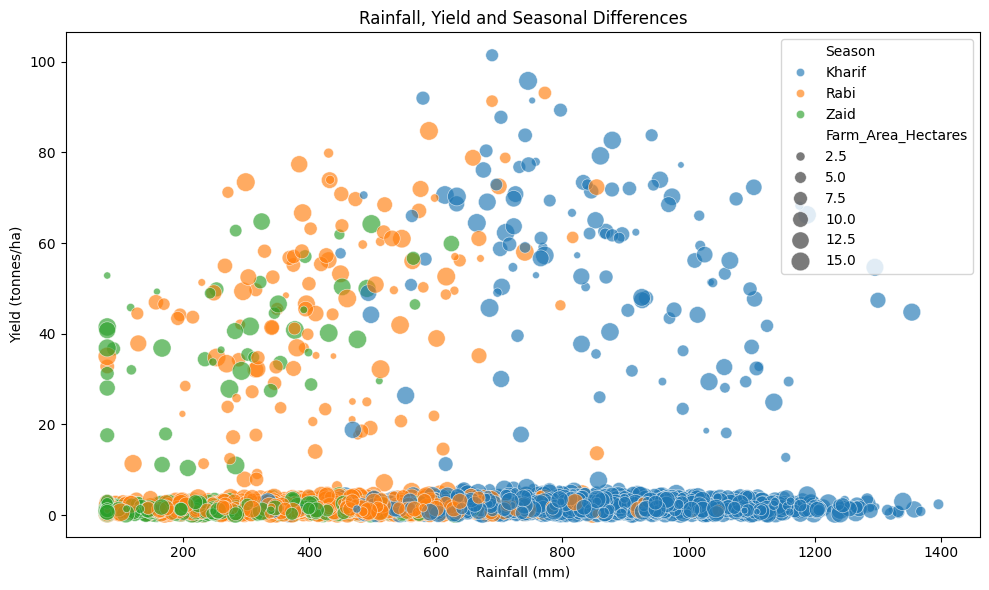

In [138]:
# Multivariate: Rainfall, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
data=df,
x="Rainfall_mm",
y="Yield_Tonnes_Ha",
hue="Season",
size="Farm_Area_Hectares",
sizes=(20, 180),
alpha=0.65
)
plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

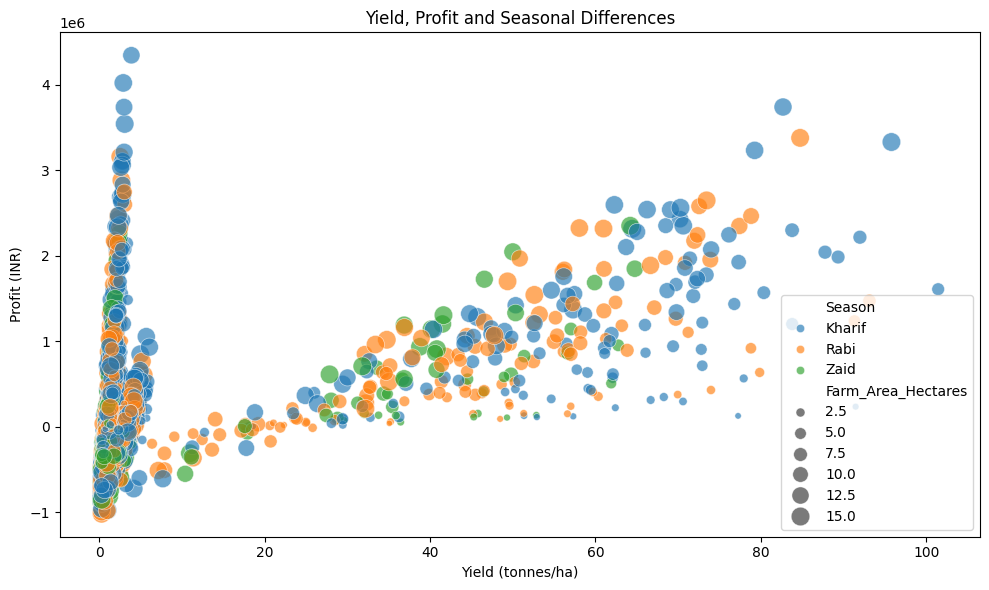

In [142]:
# Multivariate: Profit, yield and season

plt.figure(figsize=(10, 6))
sns.scatterplot(
data=df,
x="Yield_Tonnes_Ha",
y="Profit_INR",
hue="Season",
size="Farm_Area_Hectares",
sizes=(20, 180),
alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()


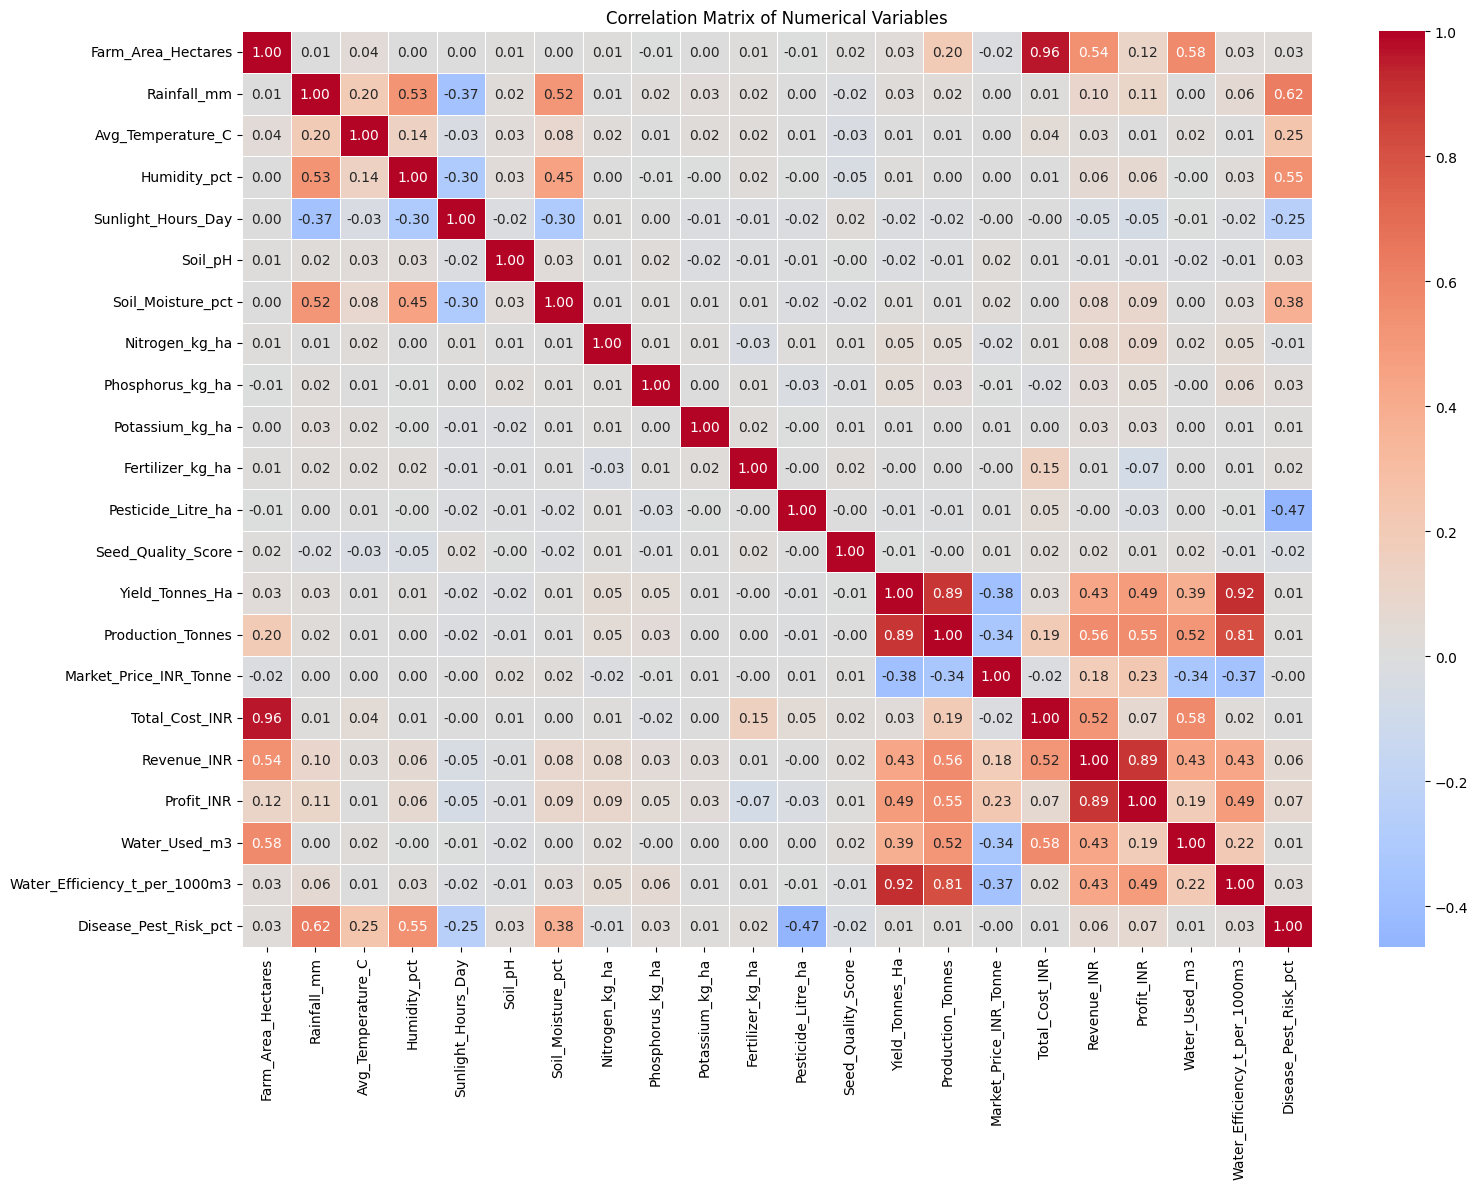

In [145]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16, 12))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [147]:
#General seasonal summary

season_metrics = df.groupby("Season").agg(

Records=("Farm_ID", "count"),
Average_Yield=("Yield_Tonnes_Ha", "mean"),
Total_Production=("Production_Tonnes", "sum"),
Average_Profit=("Profit_INR", "mean"),
Total_Profit=("Profit_INR", "sum"),
Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20
Rabi,1627,5.09,67498.88,87689.47,142670768,5846.99
Zaid,594,4.63,23098.35,-24804.82,-14734066,6419.89


In [151]:
# Compare crop performance within each season

crop_season_summary = (
df.groupby(["Season", "Crop"])
.agg(
Average_Yield=("Yield_Tonnes_Ha","mean"),
Average_Profit=("Profit_INR", "mean"),
Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
)
.round(2)
.sort_values(["Season", "Average_Yield"], ascending=[True, False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46      1000790.81                     36.00
       Maize               2.97       -39332.67                      6.05
       Rice                2.71       -64903.40                      2.17
       Wheat               2.25      -105871.87                      4.76
       Chilli              1.73       954380.42                      3.26
       Groundnut           1.48       108265.44                      3.58
       Cotton              1.37       216999.55                      2.13
       Pulses              1.04        43338.90                      3.35
Rabi   Sugarcane          43.95       731612.86                     27.92
       Maize               2.62       -89133.40                      5.46
       Rice                2.33       -98427.87                      1.84
       Wheat               2.06      -119954.57                      4.69
       Chilli              1.46       638572.50                      2.89
       Groundnut           1.23        10416.54                      2.90
       Cotton              1.19       107343.59                      1.94
       Pulses              0.87       -14309.14                      2.70
Zaid   Sugarcane          38.42       583635.80                     23.39
       Maize               2.28      -194049.17                      4.75
       Rice                1.90      -227239.34                      1.53
       Wheat               1.75      -193208.95                      4.02
       Chilli              1.18       448659.09                      2.20
       Groundnut           1.04       -68872.50                      2.47
       Cotton              0.94       -53925.34                      1.49
       Pulses              0.65      -139227.81                      1.95

Rainfall_mm         Avg_Temperature_C        Water_Used_m3          \
              mean  median              mean median          mean  median   
Season                                                                      
Kharif      852.11  854.75             28.45   28.5       6102.20  4469.0   
Rabi        435.94  430.30             23.49   23.5       5846.99  4292.0   
Zaid        299.12  283.30             31.04   31.0       6419.89  4805.0   

       Yield_Tonnes_Ha        Water_Efficiency_t_per_1000m3         \
                  mean median                          mean median   
Season                                                               
Kharif            5.63   1.94                          5.89   3.28   
Rabi              5.09   1.66                          5.19   2.74   
Zaid              4.63   1.45                          4.41   2.30   

       Total_Cost_INR           Revenue_INR           Profit_INR           
                 mean    median        mean    median       mean   median  
Season                                                                     
Kharif      531804.41  524840.0   710719.06  520196.0  178914.65  38808.0  
Rabi        513836.58  506733.0   601526.05  438156.0   87689.47  -3187.0  
Zaid        543976.73  534833.0   519171.90  373700.5  -24804.82 -62144.0

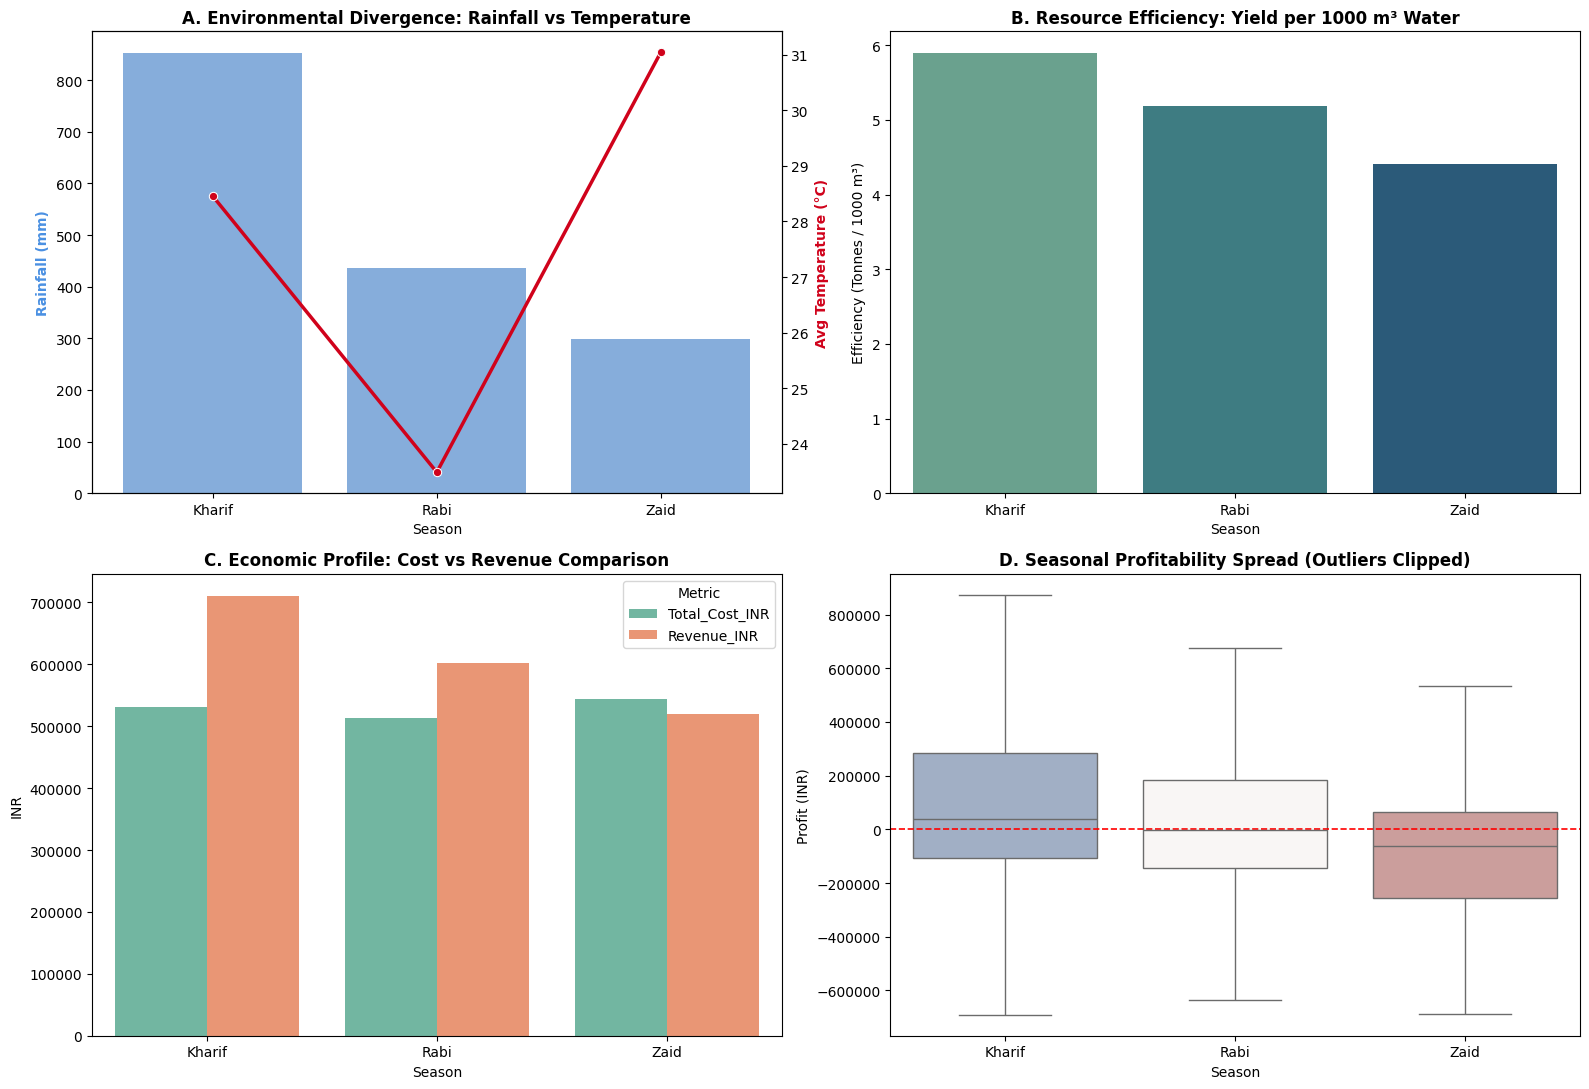

In [153]:
# 1. Feature Selection across the 4 core dimensions
comparison_metrics = {
    'Rainfall_mm': 'Mean Rainfall (mm)',
    'Avg_Temperature_C': 'Mean Temp (°C)',
    'Water_Used_m3': 'Mean Water Used (m³)',
    'Yield_Tonnes_Ha': 'Mean Yield (t/ha)',
    'Water_Efficiency_t_per_1000m3': 'Water Efficiency (t/1000m³)',
    'Total_Cost_INR': 'Mean Cost (INR)',
    'Revenue_INR': 'Mean Revenue (INR)',
    'Profit_INR': 'Mean Profit (INR)'
}

# 2. Structured Comparison Table (Mean & Median)
seasonal_summary = df.groupby('Season')[list(comparison_metrics.keys())].agg(['mean', 'median']).round(2)
display(seasonal_summary)

# 3. 2x2 Structured Comparative Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Panel A: Environmental Variation
env_df = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C']].mean().reset_index()
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
sns.barplot(data=env_df, x='Season', y='Rainfall_mm', hue='Season', ax=ax1, palette=['#4A90E2']*3, alpha=0.75, legend=False)
sns.lineplot(data=env_df, x='Season', y='Avg_Temperature_C', ax=ax1_twin, color='#D0021B', marker='o', linewidth=2.5)
ax1.set_ylabel('Rainfall (mm)', color='#4A90E2', fontweight='bold')
ax1_twin.set_ylabel('Avg Temperature (°C)', color='#D0021B', fontweight='bold')
ax1.set_title('A. Environmental Divergence: Rainfall vs Temperature', fontweight='bold')

# Panel B: Productivity & Water Efficiency
sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', hue='Season', ax=axes[0, 1], palette='crest', errorbar=None, legend=False)
axes[0, 1].set_title('B. Resource Efficiency: Yield per 1000 m³ Water', fontweight='bold')
axes[0, 1].set_ylabel('Efficiency (Tonnes / 1000 m³)')

# Panel C: Economic Balance (Cost vs Revenue)
econ_melted = df.melt(id_vars=['Season'], value_vars=['Total_Cost_INR', 'Revenue_INR'], var_name='Metric', value_name='Amount')
sns.barplot(data=econ_melted, x='Season', y='Amount', hue='Metric', ax=axes[1, 0], palette='Set2', errorbar=None)
axes[1, 0].set_title('C. Economic Profile: Cost vs Revenue Comparison', fontweight='bold')
axes[1, 0].set_ylabel('INR')

# Panel D: Net Profitability Distribution
sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', ax=axes[1, 1], palette='vlag', showfliers=False, legend=False)
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[1, 1].set_title('D. Seasonal Profitability Spread (Outliers Clipped)', fontweight='bold')
axes[1, 1].set_ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

## 📊 Key Empirical Insights from Analysis

Based on our comprehensive exploratory data analysis, here are the 8 key empirical insights:

1. **Sugarcane Outliers Drive Overall Production and Yield Heat**: Sugarcane acts as a massive statistical outlier across all seasons, with yields averaging over 38–53 tonnes/ha. This is nearly 15–20 times the average yield of any other crop (such as Rice, Maize, or Wheat which stay below 3 tonnes/ha).

2. **Kharif Season Maximizes Profitability**: The Kharif season is the primary driver of economic surplus, yielding a massive net total profit of **318.29 million INR** and an average profit of **178,914.65 INR** per farm, fueled by naturally high precipitation (**852.11 mm** average) reducing artificial irrigation costs.

3. **Zaid is Economically Unviable**: Farming during the hot, dry Zaid season is on average unprofitable, posting an average net loss of **-24,804.82 INR** per farm and an overall net loss of **-14.73 million INR** across the dataset due to elevated temperatures (**31.04 °C**) and expensive supplementary water usage.

4. **Drip Irrigation is Highly Superior**: Drip irrigation yields the highest average farm profitability (**219,626 INR**), outperforming traditional Flood irrigation (**73,354 INR**) and Sprinklers (**91,121 INR**) by utilizing water more efficiently and boosting yield quality.

5. **Strong Area-Production Correlation**: There is an extremely strong positive correlation (**0.96**) between `Farm_Area_Hectares` and `Total_Cost_INR` and a strong correlation (**0.54**) with `Revenue_INR`. Production scale is linearly constrained by farm size.

6. **Water Usage vs. Yield Divergence**: Outside of Sugarcane, increasing water volume beyond critical crop thresholds does not linearly improve yields. The bivariate relationship between Rainfall/Water Used and Yield is highly non-linear, peaking at moderate bands and dipping at extreme volumes.

7. **Disease and Pest Risk Peaks in Kharif**: Due to high relative humidity (**71.81%**) and moderate-to-high temperatures in Kharif, the average disease/pest risk spikes significantly to **54.47%**, compared to just **38.22%** in Zaid and **40.48%** in Rabi.

8. **Severe Crop-Season Margin Squeeze**: Crop-specific margins show that non-sugarcane crops like Maize, Wheat, and Rice are highly prone to net losses across all seasons, but especially in Zaid where Maize drops to an average profit of **-194,049.17 INR** due to surging environmental maintenance costs.

## 🌾 Evidence-Based Policy and Farming Recommendations

Based on the empirical patterns extracted from the multi-seasonal data, we propose the following strategic recommendations to optimize resources, maximize profitability, and mitigate seasonal risks:

### 1. Mandate Drip Irrigation Subsidies for High-Value Crops
* **Evidence**: Drip irrigation registered the highest average profitability (**219,626 INR**), vastly outperforming flood irrigation (**73,354 INR**).
* **Action**: State agricultural departments should offer structured, tier-based capital subsidies targeting small and medium-scale farms to install drip infrastructure, prioritizing water-intensive crops like Sugarcane to decouple high yields from excessive water waste.

### 2. Disincentivize Non-Sugarcane Farming During the Zaid Season
* **Evidence**: The Zaid season incurred a net sector loss of **-14.73 million INR** due to surging environmental maintenance costs during severe heat waves (**31.04 °C** average).
* **Action**: Promote a seasonal 'fallow or cover-crop' strategy during Zaid for low-margin crops like Maize and Wheat. Offer financial incentives for farmers to switch to high-heat-tolerant, low-water pulses or legumes, or to leave fields fallow to regenerate soil nutrients.

### 3. Deploy Targeted IPM Systems in Kharif to Counter Monsoon Pest Cycles
* **Evidence**: Disease and pest risks peak aggressively during the Kharif season at **54.47%** due to high relative humidity (**71.81%**).
* **Action**: Launch localized mobile SMS warning alerts and subsidize Integrated Pest Management (IPM) kits (such as pheromone traps and bio-pesticides) specifically at the onset of the Kharif monsoon. This will prevent high crop losses without inflating chemical pesticide input costs.

### 4. Cap and Penalize Flood Irrigation for Sugarcane Cultivation
* **Evidence**: Sugarcane yields are highly lucrative, yet overall water consumption averages **6,045 m³** per cycle. Increasing water volume beyond crop thresholds does not yield a linear return.
* **Action**: Implement local ground-water extraction caps during Rabi and Zaid. Transition sugarcane farmers away from water-inefficient flood irrigation by introducing a volumetric water tariff system, combined with credit incentives for those adopting water-efficient drip setups.

## ⚠️ Project Limitations, Dataset Gaps, and Modeling Assumptions

To ensure a professional and transparent final report, we must document the analytical boundaries of this dataset, identify critical data gaps, and state the underlying assumptions of our recommendations:

### 1. Spatial and Temporal Granularity
* **Absence of Micro-Climatic Data**: The dataset reports broad seasonal metrics (e.g., average seasonal temperature and rainfall). However, crop health and yield are heavily dictated by high-resolution daily variables such as sudden heatwaves, prolonged dry spells, or localized frost nights, which are obscured by seasonal averages.
* **Geographic Simplification**: Aggregating diverse micro-climates into broad state-level and district-level classifications limits localized precision. Soil qualities, slope, and water tables can vary dramatically within a single district, meaning a policy that works in one part of a district may fail in another.

### 2. Dataset Bias & Outlier Effects
* **The Sugarcane Yield Distortion**: As observed during the EDA, Sugarcane yields (38–53 tonnes/ha) act as extreme statistical outliers compared to all other crops (typically < 3 tonnes/ha). Any aggregated models or global water efficiency calculations will be heavily skewed by Sugarcane unless properly segmented by crop type.
* **Lack of Historical Longitudinal Baseline**: The dataset provides a single snapshot of observations rather than a multi-year time-series. It is impossible to determine whether the high unprofitable rates in the Zaid season are an ongoing structural issue or simply the result of a single anomalous drought year (e.g., an El Niño cycle).

### 3. Economic and Operational Assumptions
* **Static Market Prices and Input Costs**: The dataset models market prices and farm costs as static parameters per observation. In reality, agricultural markets are highly volatile, influenced by real-time factors like transport fuel costs, government Minimum Support Prices (MSP), and regional middlemen pricing structures.
* **Assumption of Metering Infrastructure**: Our policy recommendation to implement volumetric water pricing for sugarcane assumes the existence of reliable, tamper-proof, and affordable water-metering infrastructure across thousands of rural farms—an assumption that poses massive logistical and capital-expense hurdles in practice.

### 4. Human and Ecological Factors
* **Omission of Farm Demographics & Labor**: Factors such as farmer age, education level, household size, and credit availability are primary drivers of technology adoption (such as switching to drip irrigation) but are entirely absent from this dataset.
* **Simplified Pest Risk Metrics**: Pest risk is modeled as a simple seasonal percentage. In practice, pest dynamics are highly species-specific and crop-specific, requiring complex biological models rather than generic meteorological correlations.